<a href="https://colab.research.google.com/github/Anuoluwapo65/pytorch-jax-implementation/blob/main/vision_Transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
### import standard libraries######
import os
import time
import json
import tqdm.notebook as tqdm
import copy
from collections import defaultdict


import matplotlib.pyplot as plt
import matplotlib.colors
import seaborn as sns
sns.set_theme()
import numpy as np

import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
from torchvision import datasets
import torch.utils.data as data
from torch.utils.data import DataLoader

In [2]:
#@title Clone, Install, Import
!git clone https://github.com/ssanya942/MICCAI-Educational-Challenge-2024.git


Cloning into 'MICCAI-Educational-Challenge-2024'...
remote: Enumerating objects: 606, done.
remote: Counting objects: 100% (606/606), done.
remote: Compressing objects: 100% (606/606), done.
remote: Total 606 (delta 54), reused 508 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (606/606), 9.95 MiB | 26.46 MiB/s, done.
Resolving deltas: 100% (54/54), done.


In [3]:
train_dir = '/content/MICCAI-Educational-Challenge-2024/train'
test_dir = '/content/MICCAI-Educational-Challenge-2024/test'

Num_workers = os.cpu_count()

def create_data_loader(train_dir:str, test_dir:str, batch_size:int, shuffle:True, transform : transforms.Compose, num_workers:int = Num_workers):

  train_data = datasets.ImageFolder(train_dir, transform = transform)
  test_data = datasets.ImageFolder(test_dir, transform = transform)


  train_data_loader = DataLoader(train_data, batch_size = batch_size, shuffle = True, num_workers = num_workers, pin_memory= True)

  test_data_loader = DataLoader(test_data, batch_size = batch_size, shuffle = False, num_workers = num_workers, pin_memory = True)

  create_classes = train_data.classes


  return train_data_loader, test_data_loader, create_classes

In [4]:
IMG_SIZE = 224
manual_transforms = transforms.Compose([transforms.ToTensor(),
                                transforms.Resize((IMG_SIZE, IMG_SIZE)),
                               transforms.RandomHorizontalFlip(p = 0.5),
                               transforms.RandomVerticalFlip(p = 0.5)])

print(f"the transformation for transforming the data {manual_transforms}")

the transformation for transforming the data Compose(
    ToTensor()
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomVerticalFlip(p=0.5)
)


In [5]:
#@title Clone, Install, Import
!rm -rf MICCAI-Educational-Challenge-2024 # Remove existing directory to ensure a clean clone
!git clone https://github.com/ssanya942/MICCAI-Educational-Challenge-2024.git

Cloning into 'MICCAI-Educational-Challenge-2024'...
remote: Enumerating objects: 606, done.
remote: Counting objects: 100% (606/606), done.
remote: Compressing objects: 100% (606/606), done.
remote: Total 606 (delta 54), reused 508 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (606/606), 9.95 MiB | 22.94 MiB/s, done.
Resolving deltas: 100% (54/54), done.


In [6]:
BATCH_SIZE = 32

# Create data loaders
train_dataloader, test_dataloader, class_names = create_data_loader(
    train_dir=train_dir,
    test_dir=test_dir,
    transform=manual_transforms, ## defined above
    batch_size=BATCH_SIZE,
    shuffle = True
)

train_dataloader, test_dataloader, class_names

(<torch.utils.data.dataloader.DataLoader at 0x7b7c1247a750>,
 ['infected', 'uninfected'])

 the shape of the images torch.Size([3, 224, 224])
the shape of the labels torch.Size([])


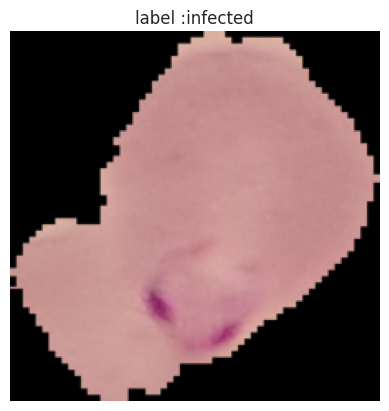

In [7]:
images_batch, labels_batch = next(iter(train_dataloader))
images, labels = images_batch[0], labels_batch[0]

print(f" the shape of the images {images.shape}")
print(f"the shape of the labels {labels.shape}")

plt.imshow(images.permute(1,2, 0 ))
plt.title(f"label :{class_names[labels]}")
plt.axis(False);



In [8]:
patch_size = 32



In [9]:
class patch_embedding(nn.Module):
  def __init__(self, in_channels:int = 3, patch_size:int = 16, embedding_dim:int = 768):
    super().__init__()




    self.patcher = nn.Conv2d(in_channels= in_channels,
                             out_channels = embedding_dim,
                             kernel_size = patch_size,
                             stride =  patch_size,
                             padding = 0)

    self.flatten = nn.Flatten(start_dim = 2, end_dim = 3)

  def forward(self, x):
    image_resolution = x.shape[-1]
    assert image_resolution % patch_size == 0,f"image_resolution must be divisible my patch_size, and must be equivalent to zero, image shape :{image_resolution.shape}, path_size shape : {patch_size.shape}"


    x_patcher = self.patcher(x)
    x_flatten = self.flatten(x_patcher)






    return x_flatten.permute(0, 2, 1)






In [10]:
patch_size = 16

def set_seed(seed: int = 42):
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)

set_seed()


patchify = patch_embedding(in_channels = 3, patch_size = 16, embedding_dim = 768)


print(f"the input image {images.unsqueeze(0).shape}")

pactified = patchify(images.unsqueeze(0))

print(f"added an extra batch to the image dimension {pactified.shape}")

print(pactified)


the input image torch.Size([1, 3, 224, 224])
added an extra batch to the image dimension torch.Size([1, 196, 768])
tensor([[[-0.0188, -0.0114, -0.0311,  ...,  0.0105, -0.0033,  0.0033],
         [-0.0188, -0.0114, -0.0311,  ...,  0.0105, -0.0033,  0.0033],
         [-0.0188, -0.0114, -0.0311,  ...,  0.0105, -0.0033,  0.0033],
         ...,
         [-0.0188, -0.0114, -0.0311,  ...,  0.0105, -0.0033,  0.0033],
         [-0.0188, -0.0114, -0.0311,  ...,  0.0105, -0.0033,  0.0033],
         [-0.0188, -0.0114, -0.0311,  ...,  0.0105, -0.0033,  0.0033]]],
       grad_fn=<PermuteBackward0>)


In [11]:
class MultiheadAttentionMechanism(nn.Module):
  def __init__(self, embedding_dim:int = 768, num_heads:int = 12, att_drop_out:float = 0):

    super().__init__()
    self.layer = nn.LayerNorm(normalized_shape = embedding_dim)


    self.attn = nn.MultiheadAttention(embed_dim = embedding_dim, num_heads = num_heads, dropout = att_drop_out)


  def forward(self, x):
    x = self.layer(x)
    attn_output, _= self.attn (query = x,
                         key = x,
                         value = x,
                         need_weights = False)



    return attn_output

In [12]:
class MLPBLOCK(nn.Module):
  def __init__(self, mlp_size:int=3072, embedding_dim:int=768, mlp_drop_out:float = 0):

   super().__init__()

   self.layer = nn.LayerNorm(normalized_shape=embedding_dim)


   self.mlp = nn.Sequential(
      nn.Linear(in_features=embedding_dim,
                out_features=mlp_size,
                ),
      nn.GELU(),
      nn.Dropout(p = mlp_drop_out),
      nn.Linear(in_features = mlp_size,
                out_features = embedding_dim),
      nn.Dropout(p = mlp_drop_out)
  )

  def forward(self, x):
    x = self.layer(x)
    x = self.mlp(x)
    return x

In [13]:
class TransformerEncoder(nn.Module):
  def __init__(self,
               embedding_dim:int = 768,
               mlp_size:int = 3072,
               num_heads:int = 16,
               mlp_dropout:float = 0,
               attn_dropout:float = 0):

    super().__init__()

    self.multiheadAttention = MultiheadAttentionMechanism(embedding_dim = embedding_dim,
                                                          num_heads = num_heads,
                                                          att_drop_out = attn_dropout)
    self.mlp = MLPBLOCK(embedding_dim = embedding_dim,
                        mlp_size = mlp_size,
                        mlp_drop_out = mlp_dropout)


  def forward(self, x):
    x = x + self.multiheadAttention(x)
    x = x + self.mlp(x)
    return x

In [14]:
!pip install torchinfo

In [15]:
transformer_encoders = TransformerEncoder()

from torchinfo import summary


summary(model = transformer_encoders,
        input_size = (1, 196, 768 ),
        col_width = 30,
        col_names = ["input_size", "output_size", "num_params", "trainable"],
        row_settings = ["var_names"])




Layer (type (var_name))                                 Input Shape                    Output Shape                   Param #                        Trainable
TransformerEncoder (TransformerEncoder)                 [1, 196, 768]                  [1, 196, 768]                  --                             True
├─MultiheadAttentionMechanism (multiheadAttention)      [1, 196, 768]                  [1, 196, 768]                  --                             True
│    └─LayerNorm (layer)                                [1, 196, 768]                  [1, 196, 768]                  1,536                          True
│    └─MultiheadAttention (attn)                        --                             [1, 196, 768]                  2,362,368                      True
├─MLPBLOCK (mlp)                                        [1, 196, 768]                  [1, 196, 768]                  --                             True
│    └─LayerNorm (layer)                                [1, 196, 768]  

In [16]:
class VIT(nn.Module):

  def __init__(self,
               mlp_size:int = 3072,
               image_size: int = 224,
               in_channels:int = 3,
               embedding_dim:int = 768,
               num_heads:int = 16,
               mlp_dropout:float = 0,
               attn_dropout:float = 0,
               num_classes:int = 1000,
               embeddim_dropout:float = 0,
               patch_size:int = 16,
               num_transformer_layers:int = 12):

    super().__init__()

    assert image_size % patch_size == 0, f"the image_size must be divisible by the path_size  the image size shape is {image_size}, the patch_size shape is {patch_size}"



    self.num_patches = (image_size * image_size)// patch_size **2


    self.class_embedding = nn.Parameter(data = torch.randn(1,1, embedding_dim), requires_grad = True)

    self.positional_embedding = nn.Parameter(data = torch.randn(1, 1 + self.num_patches, embedding_dim)) # Corrected positional embedding shape

    self.embedding_dropout = nn.Dropout(p = embeddim_dropout)

    self.patch_embedding = patch_embedding (in_channels = in_channels,
                                            patch_size = patch_size,
                                            embedding_dim = embedding_dim)


    self.transformer_encoders = nn.Sequential(*[TransformerEncoder(embedding_dim = embedding_dim, # Changed to TransformerEncoder class
                                                           num_heads = num_heads,
                                                           mlp_size = mlp_size,
                                                           mlp_dropout = mlp_dropout,
                                                           attn_dropout = attn_dropout,
                                                           )
    for _ in range(num_transformer_layers)])

    self.classifier = nn.Sequential(
        nn.LayerNorm(normalized_shape = embedding_dim),
        nn.Linear(in_features = embedding_dim,
                  out_features = num_classes))



  def forward(self, x):
    batch_size = x.shape[0]
    class_token = self.class_embedding.expand(batch_size, -1, -1) # Corrected class_embedding() to class_embedding
    x = self.patch_embedding(x)
    x = torch.cat([class_token, x], dim = 1)
    x = x + self.positional_embedding
    x = self.embedding_dropout(x)
    x = self.transformer_encoders(x) # Corrected typo in variable name
    x = self.classifier(x[:, 0])
    return x

In [17]:
vit = VIT(num_classes = len(class_names))
vit

VIT(
  (embedding_dropout): Dropout(p=0, inplace=False)
  (patch_embedding): patch_embedding(
    (patcher): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (flatten): Flatten(start_dim=2, end_dim=3)
  )
  (transformer_encoders): Sequential(
    (0): TransformerEncoder(
      (multiheadAttention): MultiheadAttentionMechanism(
        (layer): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
      )
      (mlp): MLPBLOCK(
        (layer): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0, inplace=False)
        )
      )
    )
    (1): TransformerEncoder(

In [18]:
%cd /content/MICCAI-Educational-Challenge-2024

/content/MICCAI-Educational-Challenge-2024


In [19]:
device = "cuda" if torch.cuda.is_available() else "cpu"
""" Set up the loss function and the optimizer and begin training on cuda"""

import engine
optimizer = torch.optim.Adam(params=vit.parameters(),
                             lr=3e-3, # Base LR from Table 3 for ViT-ImageNet-1k
                             betas=(0.9, 0.999), # default values mentioned in ViT-Base (Training & Fine-tuning)
                             weight_decay=0.3) # Default from ViT-Base Training & Fine-tuning) and Table 3 for ViT-ImageNet-1k

# Setup the loss function for multi-class classification
loss_fn = torch.nn.CrossEntropyLoss()

# Set the seeds
set_seed()

# Train the model and save the training results to a dictionary
results = engine.train(model=vit,
                       train_dataloader=train_dataloader,
                       test_dataloader=test_dataloader,
                       optimizer=optimizer,
                       loss_fn=loss_fn,
                       epochs=30,
                       device=device)


  0%|          | 0/30 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.8041 | train_acc: 0.4832 | test_loss: 0.6713 | test_acc: 0.6094
Epoch: 2 | train_loss: 0.8380 | train_acc: 0.4928 | test_loss: 0.6693 | test_acc: 0.6094
Epoch: 3 | train_loss: 0.6970 | train_acc: 0.5192 | test_loss: 0.6831 | test_acc: 0.6094
Epoch: 4 | train_loss: 0.6970 | train_acc: 0.5168 | test_loss: 0.6771 | test_acc: 0.6094
Epoch: 5 | train_loss: 0.7003 | train_acc: 0.4952 | test_loss: 0.6692 | test_acc: 0.6094
Epoch: 6 | train_loss: 0.7281 | train_acc: 0.4904 | test_loss: 0.6704 | test_acc: 0.6094
Epoch: 7 | train_loss: 0.7435 | train_acc: 0.4928 | test_loss: 0.7566 | test_acc: 0.3906
Epoch: 8 | train_loss: 0.7328 | train_acc: 0.5024 | test_loss: 0.7727 | test_acc: 0.3906
Epoch: 9 | train_loss: 0.7423 | train_acc: 0.4519 | test_loss: 0.6995 | test_acc: 0.3906
Epoch: 10 | train_loss: 0.7304 | train_acc: 0.5024 | test_loss: 0.7721 | test_acc: 0.3906
Epoch: 11 | train_loss: 0.7560 | train_acc: 0.4736 | test_loss: 0.6901 | test_acc: 0.6094
Epoch: 12 | train_l

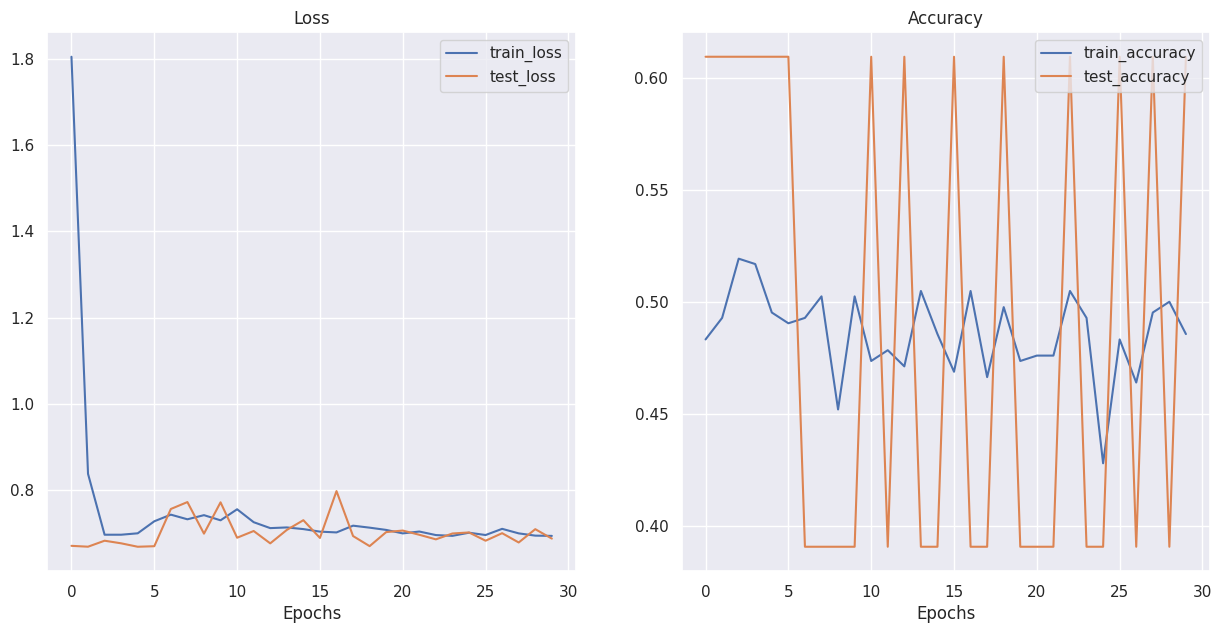

In [20]:
from helper_functions import plot_loss_curves

# Plot our ViT model's loss curves
plot_loss_curves(results)

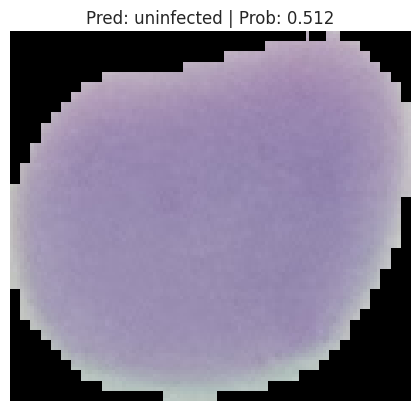

In [21]:
import requests
import predictions
from predictions import pred_and_plot_image
 #Setup custom image path
custom_image_path = "/content/MICCAI-Educational-Challenge-2024/test/uninfected/C240ThinF_IMG_20151127_115328_cell_227.png"

# Predict on custom image
pred_and_plot_image(model=vit,
                    image_path=custom_image_path,
                    class_names=class_names)